Fourier Transform is used to analyse the tendancy of sample images to be AI generated (using diffusion models) or be Real.

Import Successful


Saving 8c4bd2ed-0cdd-479a-904d-9c0f2addb17f.jpeg to 8c4bd2ed-0cdd-479a-904d-9c0f2addb17f (1).jpeg
Loaded "8c4bd2ed-0cdd-479a-904d-9c0f2addb17f (1).jpeg"  |  1024×559 px
   DC magnitude  : 71707440.00
   Mean AC mag   : 7974.03
   Peak mag (dB) : 361.76


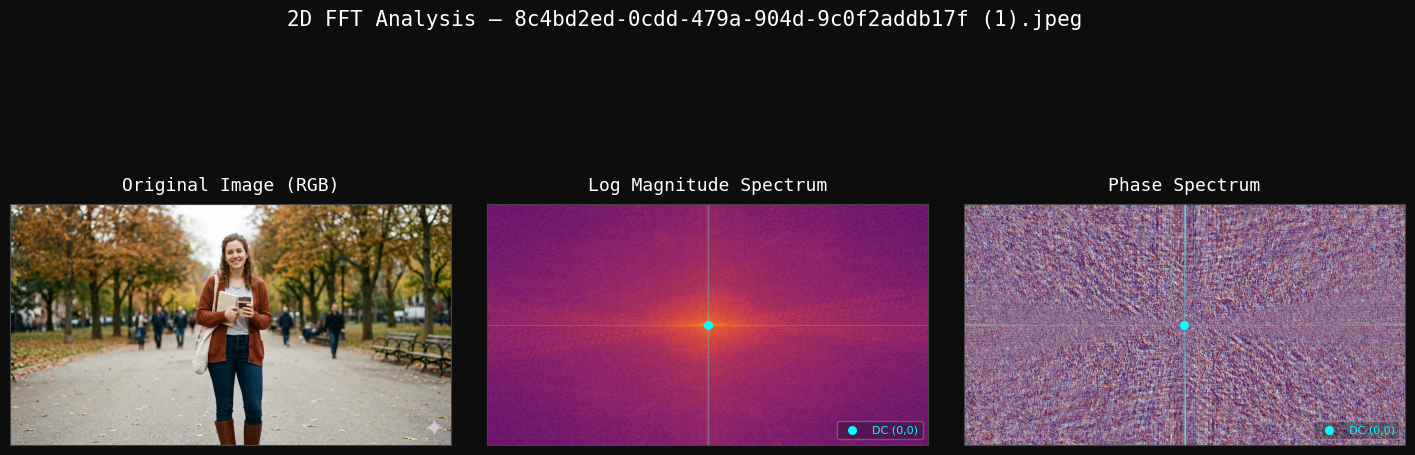

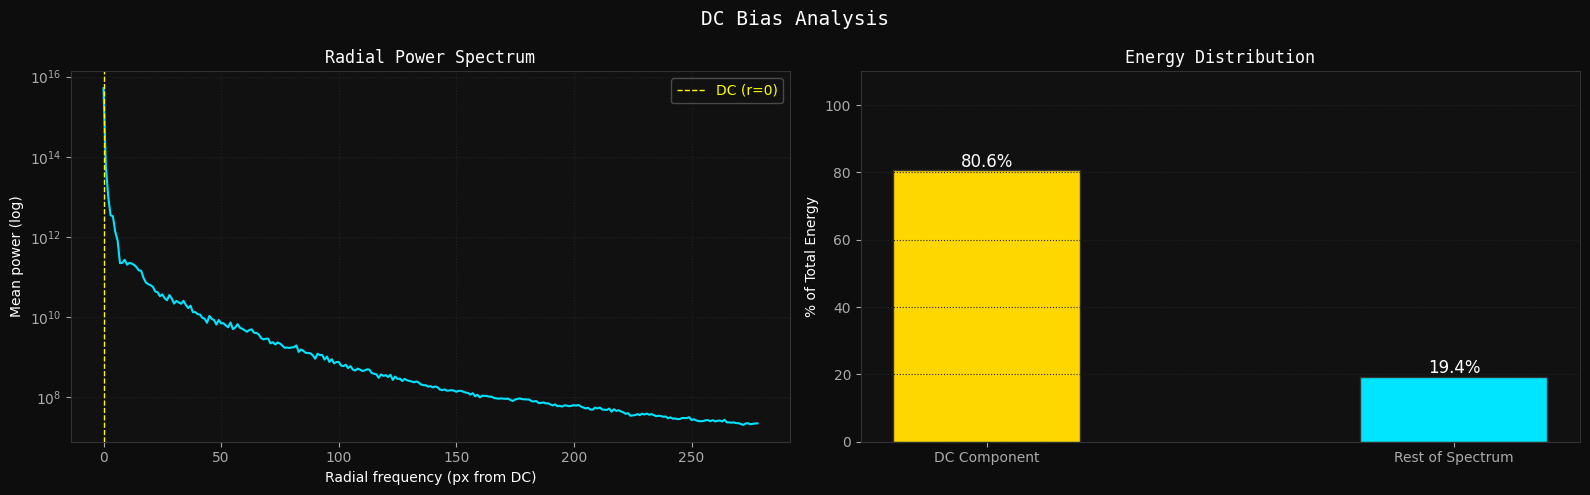

DC energy  : 80.6460%
HIGH DC bias


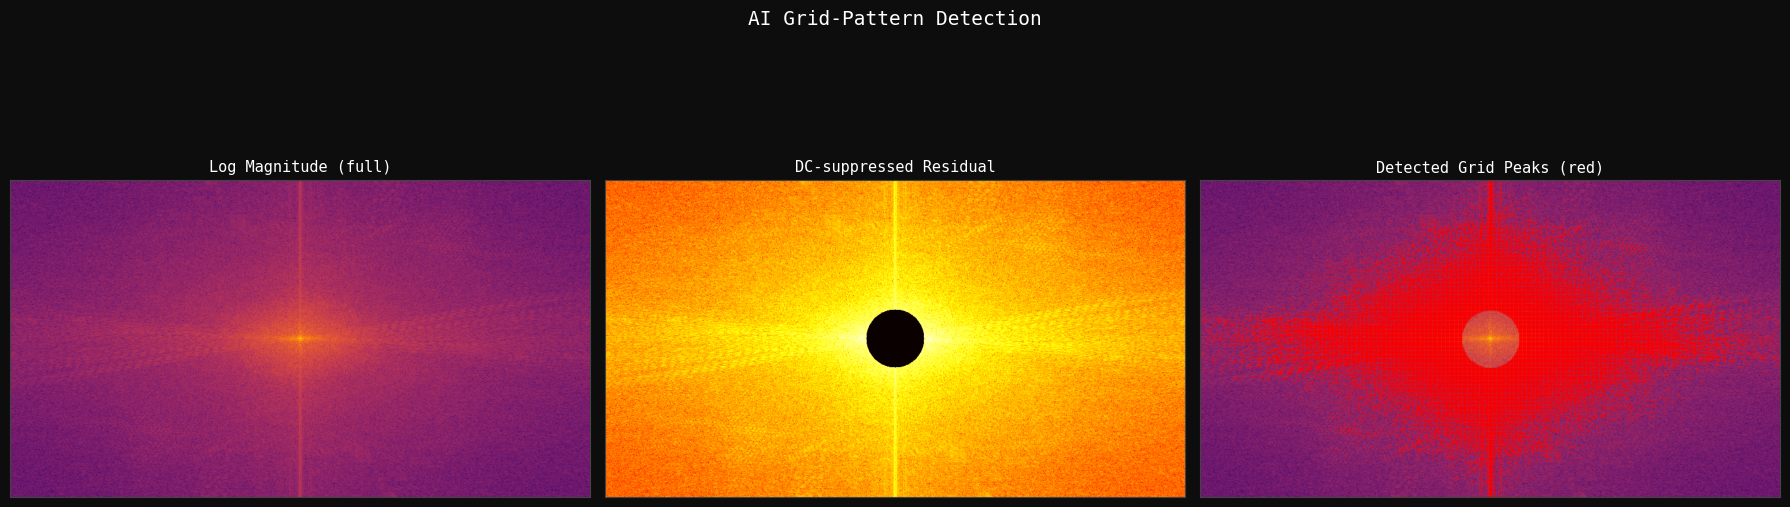

Residual peaks : 112,846  (threshold: 80th pct)
HIGH peak count → grid artifacts → LIKELY AI-generated.

  2D FFT DIAGNOSTIC SUMMARY
  Image            : 8c4bd2ed-0cdd-479a-904d-9c0f2addb17f (1).jpeg
  Dimensions       : 1024 × 559 px
  DC energy share  : 80.6460%
  Residual peaks   : 112,846
  Spectrum flatness: -15.4231  (lower = more peaked = natural)
  AI-indicator score: 1/3
  Verdict:  Ambiguous


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Downloaded: fft_overview.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Downloaded: fft_radial_power.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Downloaded: fft_ai_grid_detection.png


In [16]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "opencv-python-headless", "--quiet"], check=True)

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import files

print("Import Successful")

uploaded  = files.upload()
filename  = list(uploaded.keys())[0]

img_bytes = np.frombuffer(uploaded[filename], dtype=np.uint8)
img_color = cv2.imdecode(img_bytes, cv2.IMREAD_COLOR)
img_rgb   = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)  # RGB
img_gray  = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY) # Grayscale fourier

H, W = img_gray.shape
print(f'Loaded "{filename}"  |  {W}×{H} px')

f                  = np.fft.fft2(img_gray.astype(np.float32))
f_shift            = np.fft.fftshift(f)                        # DC - center

magnitude_spectrum = 20 * np.log1p(np.abs(f_shift))           # log
phase_spectrum     = np.angle(f_shift)                         # rd

mag_norm   = cv2.normalize(magnitude_spectrum, None, 0, 255,
                           cv2.NORM_MINMAX).astype(np.uint8)
phase_norm = cv2.normalize(phase_spectrum,     None, 0, 255,
                           cv2.NORM_MINMAX).astype(np.uint8)

cy, cx = H // 2, W // 2
print(f'   DC magnitude  : {np.abs(f_shift[cy, cx]):.2f}')
print(f'   Mean AC mag   : {np.mean(np.abs(f_shift)):.2f}')
print(f'   Peak mag (dB) : {magnitude_spectrum.max():.2f}')

fig = plt.figure(figsize=(18, 6), facecolor='#0d0d0d')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.08)

panels = [
    (img_rgb,    'Original Image (RGB)',  'gray',     False),
    (mag_norm,   'Log Magnitude Spectrum','inferno',  True ),
    (phase_norm, 'Phase Spectrum',        'twilight', True ),
]

for i, (data, title, cmap, is_fft) in enumerate(panels):
    ax = fig.add_subplot(gs[i])
    ax.imshow(data, cmap=cmap if data.ndim == 2 else None)
    ax.set_title(title, color='white', fontsize=13,
                 pad=10, fontfamily='monospace')
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_color('#444')
    if is_fft:
        ax.axhline(cy, color='cyan', lw=0.5, alpha=0.4)
        ax.axvline(cx, color='cyan', lw=0.5, alpha=0.4)
        ax.scatter([cx], [cy], c='cyan', s=30, zorder=5, label='DC (0,0)')
        ax.legend(fontsize=8, loc='lower right',
                  framealpha=0.3, labelcolor='cyan', facecolor='#111')

fig.suptitle(f'2D FFT Analysis — {filename}', color='white',
             fontsize=15, y=1.02, fontfamily='monospace')
plt.savefig('fft_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()


Y, X   = np.ogrid[:H, :W]
R      = np.sqrt((X - cx)**2 + (Y - cy)**2).astype(int)
power  = np.abs(f_shift) ** 2
r_max  = min(cx, cy)

radial_mean  = np.array([
    power[R == r].mean() if np.any(R == r) else 0
    for r in range(r_max)
])

dc_energy   = power[cy, cx]
dc_fraction = dc_energy / power.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0d0d0d')

ax = axes[0]
ax.set_facecolor('#111')
ax.semilogy(range(r_max), radial_mean + 1, color='#00e5ff', lw=1.5)
ax.axvline(0, color='yellow', lw=1, linestyle='--', label='DC (r=0)')
ax.set_xlabel('Radial frequency (px from DC)', color='white')
ax.set_ylabel('Mean power (log)',              color='white')
ax.set_title('Radial Power Spectrum',          color='white',
             fontfamily='monospace')
ax.tick_params(colors='#aaa'); ax.spines[:].set_color('#333')
ax.legend(labelcolor='yellow', facecolor='#111', framealpha=0.3)
ax.grid(True, color='#222', linestyle=':')

ax2 = axes[1]
ax2.set_facecolor('#111')
bars = ax2.bar(['DC Component', 'Rest of Spectrum'],
               [dc_fraction, 100 - dc_fraction],
               color=['#FFD700', '#00e5ff'], edgecolor='#333', width=0.4)
for bar, val in zip(bars, [dc_fraction, 100 - dc_fraction]):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center', color='white', fontsize=12)
ax2.set_ylabel('% of Total Energy', color='white')
ax2.set_title('Energy Distribution', color='white', fontfamily='monospace')
ax2.set_ylim(0, 110)
ax2.tick_params(colors='#aaa'); ax2.spines[:].set_color('#333')
ax2.grid(True, axis='y', color='#222', linestyle=':')

fig.suptitle('DC Bias Analysis', color='white',
             fontsize=14, fontfamily='monospace')
plt.tight_layout()
plt.savefig('fft_radial_power.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

print(f'DC energy  : {dc_fraction:.4f}%')
if dc_fraction > 5:
    print('HIGH DC bias')
else:
    print('LOW DC bias')


SUPPRESS_R  = max(H, W) // 20
PEAK_THRESH = 0.80   # take 20%

mag_work = magnitude_spectrum.copy()

# Zero DC
for dy in range(-SUPPRESS_R, SUPPRESS_R + 1):
    for dx in range(-SUPPRESS_R, SUPPRESS_R + 1):
        ry, rx = cy + dy, cx + dx
        if (0 <= ry < H and 0 <= rx < W
                and dy**2 + dx**2 <= SUPPRESS_R**2):
            mag_work[ry, rx] = 0.0

thresh     = np.percentile(mag_work[mag_work > 0], PEAK_THRESH * 100)
peak_mask  = mag_work > thresh
peak_count = int(peak_mask.sum())

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0d0d0d')
subtitles = ['Log Magnitude (full)',
             'DC-suppressed Residual',
             'Detected Grid Peaks (red)']
imgs      = [
    mag_norm,
    cv2.normalize(mag_work, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8),
    mag_norm,
]
cmaps_    = ['inferno', 'hot', 'inferno']

for i, (ax, img, title, cmap) in enumerate(zip(axes, imgs, subtitles, cmaps_)):
    ax.set_facecolor('#0d0d0d')
    ax.imshow(img, cmap=cmap)
    if i == 2:
        ys, xs = np.where(peak_mask)
        ax.scatter(xs, ys, s=1, c='red', alpha=0.4, linewidths=0)
    ax.set_title(title, color='white', fontsize=11, fontfamily='monospace')
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_color('#444')

fig.suptitle('AI Grid-Pattern Detection', color='white',
             fontsize=14, fontfamily='monospace', y=1.02)
plt.tight_layout()
plt.savefig('fft_ai_grid_detection.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

print(f'Residual peaks : {peak_count:,}  (threshold: {PEAK_THRESH*100:.0f}th pct)')
if peak_count > H * W * 0.01:
    print('HIGH peak count → grid artifacts → LIKELY AI-generated.')
else:
    print('LOW peak count → smooth falloff → LIKELY natural/photographic.')


# summary print
radial_std   = float(np.std(radial_mean))
radial_mean_ = float(np.mean(radial_mean))
flatness     = 1.0 - radial_std / (radial_mean_ + 1e-8)

ai_score = sum([
    dc_fraction < 5,
    peak_count > H * W * 0.01,
    flatness > 0,
])

verdicts = {
    0: ' Most likely NATURAL',
    1: ' Ambiguous',
    2: ' Probable AI',
    3: ' Strong AI',
}

print()
print('=' * 55)
print('  2D FFT DIAGNOSTIC SUMMARY')
print('=' * 55)
print(f'  Image            : {filename}')
print(f'  Dimensions       : {W} × {H} px')
print(f'  DC energy share  : {dc_fraction:.4f}%')
print(f'  Residual peaks   : {peak_count:,}')
print(f'  Spectrum flatness: {flatness:.4f}  (lower = more peaked = natural)')
print(f'  AI-indicator score: {ai_score}/3')
print(f'  Verdict: {verdicts[ai_score]}')
print('=' * 55)

for fname in ['fft_overview.png', 'fft_radial_power.png',
              'fft_ai_grid_detection.png']:
    files.download(fname)
    print(f' Downloaded: {fname}')